In [26]:
import pandas
import numpy
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import sklearn.cluster
import sklearn.metrics.pairwise
import sklearn.decomposition

***Define questions***

For our Project Part 2, we searched for the best predictors for state average SAT scores. However, say you were interested in increasing the average SAT score for a particular state. The predictors identified in Part 2 might be somewhat helpful, but it's likely that different states would have different predictors. We could redo what we did in Part 2 for each state, but that would be tedious. What if we could group states based on their educational data?

The US census bureau divides states into geographic regions for the purpose of data analysis (see: https://en.wikipedia.org/wiki/List_of_regions_of_the_United_States#Census_Bureau-designated_regions_and_divisions). It seems logical that we could do something similar, but based solely on educational data. Based on the data, we can use k-means clustering to figure out how to divide the states, and how many regions are best.

**Our Question is: How can states be divided into "regions" based on educational characteristics?** 

***Collect Data***

We'll use our SAT data set from Part 2. We also found that the National Center for Educational Statistics (NCES) publishes a lot of demographic data for each school, including full time teacher employment, student race distribution, and free/reduced lunch eligibility. However, the NCES data is only available in CSV format from 2015 onward. Thus, we'll have to switch our year of analysis to the 2015-2016 school year, as opposed to the 2014-2015 school year for Part 2. (NCES website: https://nces.ed.gov/ccd/pubschuniv.asp)

***Process Data***

For the SAT data, we can use the same cleaning techniques as from Part 2, but for the 2015 data:

In [2]:
sat_data = pandas.read_csv("../data/school_scores.csv")

In [3]:
sat_data_2015 = sat_data.loc[sat_data["Year"] == 2015, :].iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 22, 
                                                                   25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61]].copy()
sat_data_2015["Total_Overall_Score"] = sat_data_2015["Total.Math"] + sat_data_2015["Total.Verbal"]
sat_data_2015 = sat_data_2015.drop(columns = ["Total.Math", "Total.Verbal"])
total_test_takers = sat_data_2015["Total.Test-takers"]
cols = ["Family Income.Between 20-40k.Test-takers", "Family Income.Between 40-60k.Test-takers", "Family Income.Between 60-80k.Test-takers", 
        "Family Income.Between 80-100k.Test-takers", "Family Income.Less than 20k.Test-takers", "Family Income.More than 100k.Test-takers",
        "GPA.A minus.Test-takers", "GPA.A plus.Test-takers", "GPA.A.Test-takers", "GPA.B.Test-takers", "GPA.C.Test-takers", 
        "GPA.D or lower.Test-takers", "GPA.No response.Test-takers", "Gender.Female.Test-takers", "Gender.Male.Test-takers"]
for col in cols:
    sat_data_2015[col] = sat_data_2015[col]/total_test_takers
sat_data_2015 = sat_data_2015.reset_index()
sat_data_2015.head()

,index,Year,State.Code,State.Name,Total.Test-takers,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,Academic Subjects.Foreign Languages.Average GPA,...,GPA.A minus.Test-takers,GPA.A plus.Test-takers,GPA.A.Test-takers,GPA.B.Test-takers,GPA.C.Test-takers,GPA.D or lower.Test-takers,GPA.No response.Test-takers,Gender.Female.Test-takers,Gender.Male.Test-takers,Total_Overall_Score
0,524,2015,AL,Alabama,2929,3.94,2.3,3.67,4.0,3.64,...,0.189143,0.182998,0.309662,0.264254,0.031410,0.000000,0.022533,0.572209,0.427791,1088
1,525,2015,AK,Alaska,3799,3.83,2.0,3.49,3.9,3.47,...,0.181627,0.073177,0.213740,0.359832,0.089234,0.003159,0.079231,0.569097,0.430903,1014
2,526,2015,AZ,Arizona,21545,3.87,2.3,3.52,3.9,3.51,...,0.204363,0.079322,0.237642,0.364632,0.063634,0.000743,0.049663,0.557624,0.442376,1052
3,527,2015,AR,Arkansas,1207,3.94,2.5,3.73,4.0,3.74,...,0.211268,0.196355,0.355427,0.195526,0.020713,0.000000,0.020713,0.566694,0.433306,1141
4,528,2015,CA,California,241553,3.79,1.9,3.42,3.9,3.42,...,0.189892,0.043046,0.176591,0.433416,0.087207,0.001221,0.068627,0.551502,0.448498,1003


We'll now switch to cleaning the NCES data. From the NCES page linked above, we grab 3 datasets for the 2015-2016 year: the ones for membership (for getting the race/ethnicity distribution), staff (for getting full-time staff employment), and lunch program eligibility (for getting free-reduced lunch program eligibility). We'll start with membership:

In [4]:
# Read in the data, all as strings due to the weird way the data is encoded
membership_unclean = pandas.read_csv("../data/Membership_1516.csv", dtype=str)
# Select only the State Code and total num of students of each race
membership_unclean = membership_unclean[["STABR", "AM", "AS", "HI", "BL", "WH", "HP", "TR"]]
# Get number columns back to ints
membership_unclean[["AM", "AS", "HI", "BL", "WH", "HP", "TR"]] = membership_unclean[["AM", "AS", "HI", "BL", "WH", "HP", "TR"]].astype(int)
# Replace any negatives with NaN
membership_clean = membership_unclean.replace(-1, numpy.nan).replace(-2, numpy.nan).replace(-9, numpy.nan)
for col in ["AM", "AS", "HI", "BL", "WH", "HP", "TR"]:
    # Replace any NaNs with the mean for the state
    membership_clean[col] = membership_clean[col].fillna(membership_clean.groupby("STABR")[col].transform("mean"))
    # If the state doesn't report in that racial category at all, impute with 0
    # Mainly because NY doesn't break out Hawaiian Native/Pacific Islander as a seperate group
    membership_clean[col] = membership_clean[col].fillna(0)
# Calculate total students per school 
membership_clean["TotalStudents"] = (membership_clean["AM"] + membership_clean["AS"] + membership_clean["HI"] + membership_clean["BL"] 
                                        + membership_clean["WH"] + membership_clean["HP"] + membership_clean["TR"])
# Calculate overall state totals, give columns clearer names
membership_totals = (membership_clean.groupby("STABR").sum()
                  .reset_index()).rename(columns={"STABR": "State.Code","AM": "AmericanIndianAlaskanNative", "AS": "Asian", "HI": "Hispanic",
                                                 "BL": "Black", "WH": "White", "HP": "HawaiianNativePacificIslander", 
                                                  "TR": "TwoOrMoreRaces"})
# Drop data for Bureau of Indian Affairs, Department of Defense, and Guam schools
membership_totals = (membership_totals.drop([4, 9, 13])).reset_index(drop = True)
# Convert to get relative racial/ethnic distribution for each state
for col in ["AmericanIndianAlaskanNative", "Asian", "Hispanic", "Black", "White", "HawaiianNativePacificIslander", "TwoOrMoreRaces"]:
    membership_totals[col] = membership_totals[col]/membership_totals["TotalStudents"]

In [5]:
membership_totals.head()

,State.Code,AmericanIndianAlaskanNative,Asian,Hispanic,Black,White,HawaiianNativePacificIslander,TwoOrMoreRaces,TotalStudents
0,AK,0.230583,0.059376,0.066578,0.031636,0.481457,0.027114,0.103256,1.324770e+05
1,AL,0.008835,0.014023,0.068233,0.332184,0.556319,0.000902,0.019504,8.216540e+05
2,AR,0.006360,0.015520,0.123193,0.207686,0.618289,0.006836,0.022116,4.921320e+05
3,AZ,0.045066,0.028018,0.449209,0.052778,0.394968,0.003265,0.026696,1.174507e+06
4,CA,0.005564,0.113766,0.540029,0.057806,0.240868,0.004891,0.037076,6.312578e+06


We then clean the data for free/reduced lunch eligibility. Since not all states break down the number of students who get free lunch vs the number who get only reduced price lunch (ie, they only report the total who get free OR reduced price lunch), we'll just look at the overall total. Overall, the cleaning will be similar to for the membership set:

In [6]:
# Read in the data, all as strings due to the weird way data is encoded
lunch_unclean = pandas.read_csv("../data/Lunch_1516.csv", dtype=str)
# Select only the State Code and total number of students eligible for free/reduced lunch
lunch_unclean = lunch_unclean[["STABR", "TOTFRL"]]
# Get numerical column back to an int type
lunch_unclean[["TOTFRL"]] = lunch_unclean[["TOTFRL"]].astype(int)
# Replace any negatives with NaN
lunch_unclean = lunch_unclean.replace(-1, numpy.nan).replace(-2, numpy.nan).replace(-9, numpy.nan)
# Replace NaN with state average
lunch_unclean["TOTFRL"] = lunch_unclean["TOTFRL"].fillna(lunch_unclean.groupby("STABR")["TOTFRL"].transform("mean"))
# Sum up each state
lunch_totals = (lunch_unclean.groupby("STABR").sum().reset_index()).rename(columns = {"STABR": "State.Code", "TOTFRL": "FreeReducedLunch"})
# Drop data for Bureau of Indian Affairs, Department of Defense, and Guam schools
lunch_totals = (lunch_totals.drop([4, 9, 13])).reset_index(drop = True)

In [7]:
lunch_totals.head()

,State.Code,FreeReducedLunch
0,AK,5.707440e+04
1,AL,4.204029e+05
2,AR,3.210340e+05
3,AZ,6.909038e+05
4,CA,3.755197e+06


Finally, we clean the data for full-time teacher employment. Note that this is NOT the exact number of full time teachers employed by the school. It is an estimate "computed by dividing the amount of time employed by the amount of time normally required for a full-time position." (quoted from https://nces.ed.gov/ccd/pdf/CCD_201516_File_Documentation_2017074.pdf). Nevertheless, it is still a useful metric, particularly for computing the state student to teacher ratio. We do the data cleaning much the same way as for the free/reduced lunch data:

In [8]:
# Read in the data, all as strings due to the weird way data is encoded
staff_unclean = pandas.read_csv("../data/Staff_1516.csv", dtype=str)
# Select only the State Code and equivalent number of full time educators
staff_unclean = staff_unclean[["STABR", "FTE"]]
# Get numerical column to a double type
staff_unclean[["FTE"]] = staff_unclean[["FTE"]].astype(float)
# Replace any negatives with NaN
staff_unclean = staff_unclean.replace(-1, numpy.nan).replace(-2, numpy.nan).replace(-9, numpy.nan)
# Sum up each state
staff_totals = (staff_unclean.groupby("STABR").sum().reset_index()).rename(columns = {"STABR": "State.Code", "FTE": "EquivFullTimeTeachers"})
# Drop data for American Samoa, Bureau of Indian Affairs, Department of Defense, and Guam schools
staff_totals = (staff_totals.drop([3, 5, 10, 14])).reset_index(drop = True)

In [9]:
staff_totals.head()

,State.Code,EquivFullTimeTeachers
0,AK,7777.88
1,AL,42161.58
2,AR,35803.87
3,AZ,47642.34
4,CA,262503.20


We can then merge all of the demographic data into one larger data frame:

In [10]:
# Merge Data
temp = pandas.merge(membership_totals, lunch_totals, how = "inner", on = "State.Code")
demographic_totals = pandas.merge(temp, staff_totals, how = "inner", on = "State.Code")

We then do a few final imputations. A few states didn't report the full time teacher employment, so that was imputated by the national average full-time teacher employment. Also, Massachusetts did not submit free or reduced-price lunch data, so the proportion was imputated from the national average, then applied to the total number of students in Massachusetts.

In [11]:
# Calculate Proportion of students getting free reduced lunch
demographic_totals["FreeReducedLunchProp"] = demographic_totals["FreeReducedLunch"]/demographic_totals["TotalStudents"]
# Massachusetts doesn't have free/reduced lunch data, so impute with national mean
demographic_totals["FreeReducedLunchProp"] = (demographic_totals["FreeReducedLunchProp"].replace(0, numpy.nan)
                                                .fillna(demographic_totals["FreeReducedLunchProp"].mean(skipna=True)))
# Some states don't equivalent full time educator data, so impute with national mean
demographic_totals["EquivFullTimeTeachers"] = (demographic_totals["EquivFullTimeTeachers"].replace(0, numpy.nan)
                                                .fillna(demographic_totals["EquivFullTimeTeachers"].mean(skipna=True)))
# Calculate Student Teacher ratio
demographic_totals["StudentTeacherRatio"] = demographic_totals["TotalStudents"]/demographic_totals["EquivFullTimeTeachers"]

In [12]:
# Manually calculate imputed number of students in MA eligible for free/reduced lunch from imputed proportion
# Might not end up needing, but fun to have 
demographic_totals.loc[19, "FreeReducedLunch"] = 0.512580 * 9.534230e+05

We then merge the SAT and demographic data sets into a larger, combined data set:

In [13]:
full_combined_data_2015 = pandas.merge(sat_data_2015, demographic_totals, how = "inner", on = "State.Code").drop(columns = ["index"])
full_combined_data_2015.head()

,Year,State.Code,State.Name,Total.Test-takers,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,Academic Subjects.Foreign Languages.Average GPA,Academic Subjects.Foreign Languages.Average Years,...,Hispanic,Black,White,HawaiianNativePacificIslander,TwoOrMoreRaces,TotalStudents,FreeReducedLunch,EquivFullTimeTeachers,FreeReducedLunchProp,StudentTeacherRatio
0,2015,AL,Alabama,2929,3.94,2.3,3.67,4.0,3.64,2.5,...,0.068233,0.332184,0.556319,0.000902,0.019504,8.216540e+05,4.204029e+05,42161.58,0.511654,19.488216
1,2015,AK,Alaska,3799,3.83,2.0,3.49,3.9,3.47,2.2,...,0.066578,0.031636,0.481457,0.027114,0.103256,1.324770e+05,5.707440e+04,7777.88,0.430825,17.032533
2,2015,AZ,Arizona,21545,3.87,2.3,3.52,3.9,3.51,2.5,...,0.449209,0.052778,0.394968,0.003265,0.026696,1.174507e+06,6.909038e+05,47642.34,0.588250,24.652589
3,2015,AR,Arkansas,1207,3.94,2.5,3.73,4.0,3.74,2.6,...,0.123193,0.207686,0.618289,0.006836,0.022116,4.921320e+05,3.210340e+05,35803.87,0.652333,13.745218
4,2015,CA,California,241553,3.79,1.9,3.42,3.9,3.42,2.8,...,0.540029,0.057806,0.240868,0.004891,0.037076,6.312578e+06,3.755197e+06,262503.20,0.594875,24.047623


In [14]:
# Data without any non-normalized variables
trimmed_combined_data_2015 = full_combined_data_2015.drop(columns = ["Total.Test-takers", "TotalStudents", "FreeReducedLunch", "EquivFullTimeTeachers"])
# Only predictors from Part 2 - used for new linear model
only_predictors_data_2015 = full_combined_data_2015[["Total_Overall_Score", "Academic Subjects.Arts/Music.Average GPA", 
                                                     "Academic Subjects.English.Average GPA", 
                                                     "Academic Subjects.Foreign Languages.Average GPA", 
                                                     "Academic Subjects.Mathematics.Average GPA", 
                                                     "Academic Subjects.Natural Sciences.Average GPA",
                                                     "Academic Subjects.Social Sciences/History.Average GPA",
                                                     "Academic Subjects.Arts/Music.Average Years",  
                                                     "Academic Subjects.English.Average Years",
                                                     "Academic Subjects.Mathematics.Average Years",
                                                     "Academic Subjects.Natural Sciences.Average Years",
                                                     "Family Income.Less than 20k.Test-takers", "Family Income.Between 20-40k.Test-takers",
                                                     "Family Income.Between 60-80k.Test-takers", "Family Income.Between 80-100k.Test-takers",
                                                     "Family Income.More than 100k.Test-takers", 'GPA.D or lower.Test-takers',
                                                     'GPA.A plus.Test-takers', 'GPA.No response.Test-takers', 'GPA.A.Test-takers',
                                                     'GPA.A minus.Test-takers']]
predictors_new_vars = full_combined_data_2015[["Total_Overall_Score", "Academic Subjects.Arts/Music.Average GPA",
                                               "Academic Subjects.English.Average GPA", "Academic Subjects.Foreign Languages.Average GPA",
                                               "Academic Subjects.Mathematics.Average GPA", "Academic Subjects.Natural Sciences.Average GPA",
                                               "Academic Subjects.Social Sciences/History.Average GPA", 
                                               "Academic Subjects.Arts/Music.Average Years", "Academic Subjects.English.Average Years", 
                                               "Academic Subjects.Mathematics.Average Years", 
                                               "Academic Subjects.Natural Sciences.Average Years", "Family Income.Less than 20k.Test-takers",
                                               "Family Income.Between 20-40k.Test-takers", "Family Income.Between 60-80k.Test-takers", 
                                               "Family Income.Between 80-100k.Test-takers", "Family Income.More than 100k.Test-takers",
                                               'GPA.D or lower.Test-takers', 'GPA.A plus.Test-takers', 'GPA.No response.Test-takers',
                                               'GPA.A.Test-takers', 'GPA.A minus.Test-takers', "AmericanIndianAlaskanNative", "Asian",
                                               "Hispanic", "Black", "White", "HawaiianNativePacificIslander", "TwoOrMoreRaces", 
                                               "FreeReducedLunchProp", "StudentTeacherRatio"]]

**Comments and Challenges on Data Cleaning**

The data from the NCES contained data for more places then the SAT data. Namely, it contained data for schools in American Samoa (free/reduced lunch eligibity only), schools operated by the Bureau of Indian Affairs, schools operated by the Department of Defense, and schools in Guam. This data was dropped simply because there was no match in the SAT data set. It's also possible that the sets of schools in each NCES file weren't the same (ie, not all schools had data in all files). However, there is likely a large enough amount of schools for each state that the subtraction of a few wouldn't have a huge effect on the data. Finally, the NCES data only covers public schools, while the SAT data covers all students who took the SAT in the state, including students who don't go to public school. However, it is likely that the number of such students is small enough that it wouldn't meaningfully affect the demographics.

**2014 vs 2015 Model Stability Check**

To include regional SAT factors in our project, we had to use a demographic dataset from 2015, while our main SAT analysis uses 2014 data. To make sure the 2015 data is still valid for our model, we compared the two years using linear regression. This method helps us see whether the same factors predict SAT scores in a similar way across both years. If the models show similar accuracy and coefficients, we can be confident that using the 2015 dataset won’t disrupt the overall analysis.

In [15]:
sat_data_2014 = sat_data.loc[sat_data["Year"] == 2014, :].iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 22, 
                                                                   25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61]].copy()

# Compute total SAT score for 2014
sat_data_2014["Total_Overall_Score"] = sat_data_2014["Total.Math"] + sat_data_2014["Total.Verbal"]
sat_data_2014 = sat_data_2014.drop(columns=["Total.Math", "Total.Verbal"])

# Normalize the same percentage columns
total_test_takers_2014 = sat_data_2014["Total.Test-takers"]
for col in cols:  # `cols` already defined in your notebook
    sat_data_2014[col] = sat_data_2014[col] / total_test_takers_2014

sat_data_2014 = sat_data_2014.reset_index()

gpa_cols = [
    "Academic Subjects.Arts/Music.Average GPA",
    "Academic Subjects.English.Average GPA",
    "Academic Subjects.Foreign Languages.Average GPA",
    "Academic Subjects.Mathematics.Average GPA",
    "Academic Subjects.Natural Sciences.Average GPA",
    "Academic Subjects.Social Sciences/History.Average GPA"
]

x14 = sat_data_2014[gpa_cols]
y14 = sat_data_2014["Total_Overall_Score"]

x15 = sat_data_2015[gpa_cols]
y15 = sat_data_2015["Total_Overall_Score"]

model14 = LinearRegression().fit(x14, y14)
model15 = LinearRegression().fit(x15, y15)

print("2014 R²:", model14.score(x14, y14))
print("2015 R²:", model15.score(x15, y15))

coef_table = pandas.DataFrame({
    "Subject": gpa_cols,
    "2014 Coefficient": model14.coef_,
    "2015 Coefficient": model15.coef_
})

coef_table["Difference (2015 - 2014)"] = (
    coef_table["2015 Coefficient"] - coef_table["2014 Coefficient"]
)

coef_table_sorted = coef_table.sort_values(
    by="Difference (2015 - 2014)",
    ascending=False
)

print(coef_table_sorted)

print("\n----- Model Stability Check -----")

r2_change = model15.score(x15, y15) - model14.score(x14, y14)
print(f"Change in R²: {r2_change:.4f}")

coef_shift = coef_table["Difference (2015 - 2014)"].abs().mean()
print(f"Mean absolute coefficient shift: {coef_shift:.2f}")

if abs(r2_change) < 0.05 and coef_shift < 50:
    print("Conclusion: GPA to SAT relationships are stable. 2015 regional analysis is justified.")
else:
    print("Conclusion: Predictive relationships changed enough to warrant caution.")

2014 R²: 0.79755810497202
2015 R²: 0.7821423782404778
                                             Subject  2014 Coefficient  \
5  Academic Subjects.Social Sciences/History.Aver...        542.555271   
3          Academic Subjects.Mathematics.Average GPA         30.419971   
2    Academic Subjects.Foreign Languages.Average GPA       -142.361981   
0           Academic Subjects.Arts/Music.Average GPA        248.344211   
1              Academic Subjects.English.Average GPA       -393.678541   
4     Academic Subjects.Natural Sciences.Average GPA        347.520441   

   2015 Coefficient  Difference (2015 - 2014)  
5        948.414998                405.859727  
3         63.333526                 32.913555  
2       -132.973767                  9.388214  
0        105.385051               -142.959160  
1       -561.551286               -167.872745  
4        155.149669               -192.370772  

----- Model Stability Check -----
Change in R²: -0.0154
Mean absolute coefficient shift: 1

**Stability Check Conclusions**

Our model comparison shows that the overall predictive accuracy of GPA variables remained highly stable between 2014 and 2015. The R² values for both years were nearly identical (0.798 in 2014 vs. 0.782 in 2015), indicating that high school GPA continued to explain roughly 78–80% of variation in SAT scores. This supports the idea that GPA-based models generalize well from 2014 to 2015 and can be used reliably for further analysis.

However, the regression coefficient comparison revealed a noticeable shift: the average GPA-to-SAT coefficient changed by approximately 158 points between years. This suggests that although GPAs remained strong predictors overall, the relative influence of specific subjects (e.g., English vs. Math vs. Sciences) changed meaningfully between the two years. Because of this, any subject-level interpretations should be made cautiously.

In summary, the overall model is stable, and 2015 regional SAT data can be used confidently, but subject-specific conclusions should acknowledge year-to-year variation.

**Clustering**

first we need to z-score normalize the data

In [22]:
data = pandas.read_csv('trimmed_data.csv')
states = data.set_index('State.Code', drop =True)
quant = states.select_dtypes(include=['number'])
norm = (quant - quant.mean())/quant.std()
norm.pop('Unnamed: 0')
norm.pop('Year')

norm.head()

,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,Academic Subjects.Foreign Languages.Average GPA,Academic Subjects.Foreign Languages.Average Years,Academic Subjects.Mathematics.Average GPA,Academic Subjects.Mathematics.Average Years,Academic Subjects.Natural Sciences.Average GPA,Academic Subjects.Natural Sciences.Average Years,...,Total_Overall_Score,AmericanIndianAlaskanNative,Asian,Hispanic,Black,White,HawaiianNativePacificIslander,TwoOrMoreRaces,FreeReducedLunchProp,StudentTeacherRatio
State.Code,,,,,,,,,,,,,,,,,,,,,
AL,1.063231,-0.144190,0.586465,0.660719,0.640653,-0.970950,0.444903,0.629643,0.672179,0.674978,...,0.243923,-0.281663,-0.534454,-0.665661,1.061272,-0.002838,-0.182004,-0.726937,-0.079677,1.359626
AK,-0.217479,-1.140980,-0.440118,-0.193381,-0.313443,-1.783481,-1.066040,-1.423962,-0.598269,-1.159577,...,-0.487472,4.796076,0.486531,-0.675017,-0.733047,-0.343319,0.447238,3.139749,-0.687417,0.508247
AZ,0.248234,-0.144190,-0.269021,-0.193381,-0.088950,-0.970950,-0.379248,0.116242,-0.333593,-1.159577,...,-0.111891,0.547963,-0.219392,1.487690,-0.606822,-0.736681,-0.125279,-0.394893,0.496230,3.150101
AR,1.063231,0.520337,0.928659,0.660719,1.201885,-0.700106,1.223268,1.143044,1.042727,0.674978,...,0.767760,-0.338343,-0.500747,-0.355018,0.318002,0.279009,-0.039561,-0.606342,0.978057,-0.631458
CA,-0.683192,-1.473243,-0.839345,-0.193381,-0.594060,-0.158418,-1.249185,-0.910560,-1.021752,-1.618216,...,-0.596193,-0.356580,1.710941,2.001022,-0.576806,-1.437544,-0.086232,0.084325,0.546044,2.940361


Then an elbow plot to find potential numbers of clusters to use.

In [31]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

In [34]:
D = sklearn.metrics.pairwise.euclidean_distances(norm.values)
n = D.shape[0]

Ks = range(1, n + 1)
inertias = []
for k in Ks:
    init_centers = norm.sort_index().iloc[:k, :].to_numpy()
    km = sklearn.cluster.KMeans(
        n_clusters=k,
        init=init_centers,
        n_init=1,
        max_iter=10,
        random_state=0
    ).fit(norm)
    inertias.append(km.inertia_)
inertias = pandas.DataFrame({'K': Ks, 'Inertia': inertias})

inertias.head()

,K,Inertia
0,1,1924.000000
1,2,1274.722900
2,3,1167.374402
3,4,1111.403053
4,5,944.814051


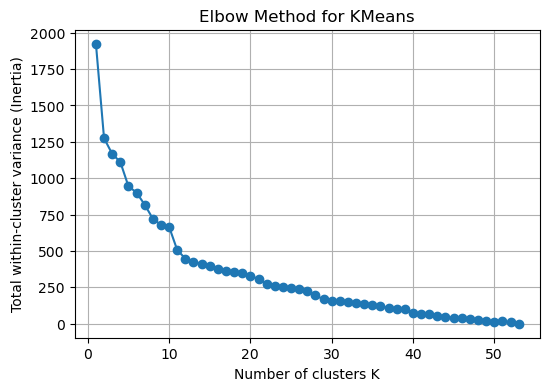

In [35]:
plt.figure(figsize=(6,4))
plt.plot(inertias['K'], inertias['Inertia'], marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Total within-cluster variance (Inertia)')
plt.title('Elbow Method for KMeans')
plt.grid(True)
plt.show()

based on this we decided to make a function in which we can do the K-means clustering for different number of clusters, however, are main choices are 4 and 5. 

In [46]:
def plot_clusters(k, norm, print_table = False, color_by_region = False):
  '''
  k- number of clusters
  norm - normalized df
  print_table - print table of clusters (default is false)
  color_by_region - used to color states by CENSUS region instead of cluster
  '''
  km = sklearn.cluster.KMeans(n_clusters = k, n_init=10, random_state=1) #change random state for different centroid initailization
  labels = km.fit_predict(norm)

  clusters = pandas.DataFrame(labels, columns=['Cluster'], index = norm.index)
  clusters['State.Code'] = clusters.index
  clusters = clusters.sort_values('Cluster')
  clusters = clusters[['State.Code', 'Cluster']]
  clusters = clusters.reset_index(drop=True)

  if print_table:
    print(f'Cluster Assignments (k={k})')
    print(clusters)
    print('\n')

  pca = sklearn.decomposition.PCA(n_components = 2, svd_solver = 'full')
  tablePCA = pca.fit_transform(norm)
  tablePCA = pandas.DataFrame(tablePCA, index = norm.index, columns = ['X', 'Y'])
  tablePCA['State'] = tablePCA.index

  plot_data = pandas.merge(clusters, tablePCA, left_on = 'State.Code', right_on = 'State')
  if color_by_region:
    state_regions = pandas.DataFrame({
    "State": ["CO", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA",
    "IL", "IN", "MI", "OH", "WI", "IA", "KS", "MN", "MO", "NE", "ND", "SD",
    "DE", "DC", "FL", "GA", "MD", "NC", "SC", "VA", "WV", "AL", "KY", "MS", "TN", "AR",
    "LA", "OK", "TX",
    "AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA", "VI", "PR"],

    "Region": [
    "Northeast", "Northeast", "Northeast", "Northeast", "Northeast",
    "Northeast", "Northeast", "Northeast", "Northeast",

    "Midwest", "Midwest", "Midwest", "Midwest", "Midwest", "Midwest",
    "Midwest", "Midwest", "Midwest", "Midwest", "Midwest", "Midwest",

    "South", "South", "South", "South", "South", "South", "South",
    "South", "South", "South", "South", "South", "South", "South",
    "South", "South", "South",

    "West", "West", "West", "West", "West", "West", "West", "West",
    "West", "West", "West", "West", "West", "Territory", "Territory"
]
})

    plot_data = pandas.merge(plot_data, state_regions, left_on='State.Code', right_on='State')
    region_colors = {'Northeast': 'red', 'Midwest': 'blue', 'South': 'green', 'West': 'orange', 'Territory': 'purple'}
    for region, color in region_colors.items():
      subset = plot_data[plot_data['Region'] == region]
      plt.scatter(
        subset['X'],
        subset['Y'],
        color=color,
        label=region
    )
    plt.title("Comparison: Geographic Regions (Census Bureau)")
    plt.legend(title="Census Region", loc="best")

  else:
    scatter = plt.scatter(plot_data['X'], plot_data['Y'], c=plot_data['Cluster'], cmap = 'tab10')
    handles, labels = scatter.legend_elements(prop="colors")
    plt.legend(handles, labels, title="Cluster", loc="best")
    plt.title(f"PCA: Educational Similarity by State (k={k})")
  for i, row in plot_data.iterrows():
    plt.text(row['X'], row['Y'], row['State.Code'], fontsize=9, alpha=0.8)
  plt.xlabel("Principal Component 1")
  plt.ylabel("Principal Component 2")
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.show()

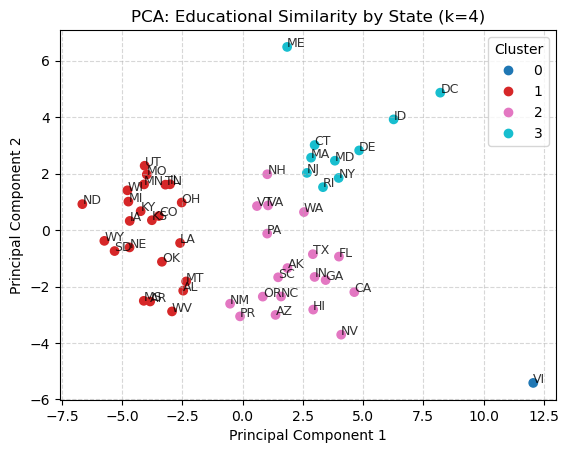

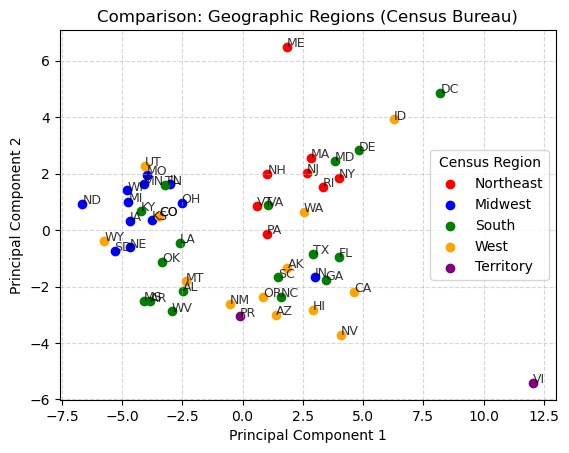

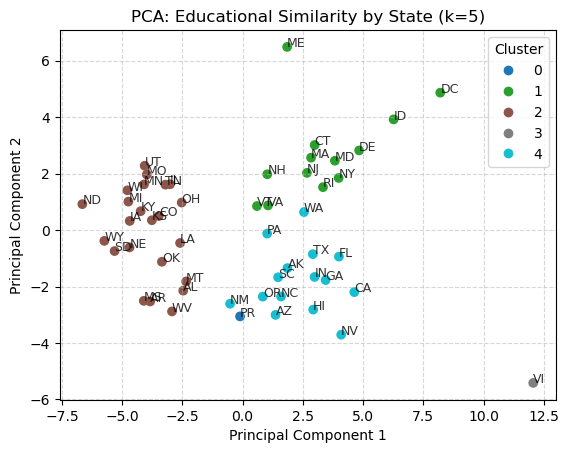

In [47]:
plot_clusters(4, norm)
plot_clusters(4, norm, color_by_region=True)
plot_clusters(5, norm)